# Training Dynamics via Persistent Homology: A Minimal Demo

**Overview:**  
This notebook demonstrates how to analyze neural network training dynamics using topological data analysis (TDA). We:
1. Train a tiny MLP on a synthetic 2D dataset
2. Extract weight matrices at training checkpoints
3. Build graph representations from weights using sublevel filtration
4. Compute persistent homology (H₀ and H₁) at each checkpoint
5. Vectorize persistence diagrams into Betti curves
6. Apply multi-dimensional spline fitting over training time
7. Visualize the evolution of topological features

**Requirements:** numpy, scipy, matplotlib, torch, sklearn, gudhi (or ripser as fallback)

In [1]:
# Uncomment to install gudhi if needed:
# !pip install gudhi

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Try to import gudhi, fallback to ripser
try:
    import gudhi
    TDA_LIBRARY = 'gudhi'
    print("Using GUDHI for persistent homology")
except ImportError:
    try:
        from ripser import ripser
        TDA_LIBRARY = 'ripser'
        print("Using Ripser for persistent homology (limited functionality)")
    except ImportError:
        raise ImportError("Please install gudhi: pip install gudhi")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Setup complete!")

Using GUDHI for persistent homology
Setup complete!


## 1. Generate Synthetic Dataset

We use sklearn's `make_moons` to create a simple 2D binary classification problem.

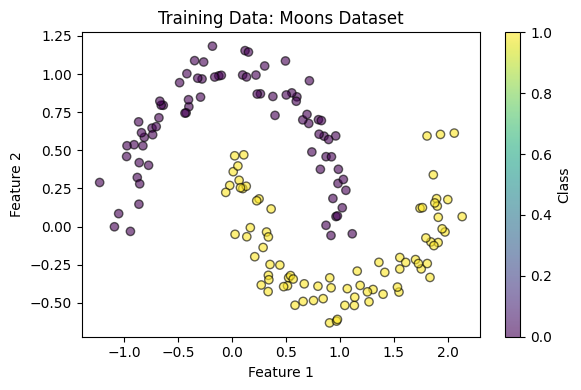

Train samples: 160, Test samples: 40


In [2]:
# Generate synthetic 2D moons dataset
n_samples = 200
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Visualize the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.6, edgecolors='k')
plt.title('Training Data: Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

## 2. Define Neural Network Model

A simple MLP with architecture: 2 → 16 → 2

In [3]:
class TinyMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=2):
        super(TinyMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model
model = TinyMLP(input_dim=2, hidden_dim=16, output_dim=2)
print(model)
print(f"\nFirst layer weight shape: {model.fc1.weight.shape}")

TinyMLP(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)

First layer weight shape: torch.Size([16, 2])


## 3. Training Loop with Checkpointing

Train the model and save checkpoints every K steps.

Starting training...
Epoch   0/100, Loss: 0.6389
Epoch  20/100, Loss: 0.5836
Epoch  40/100, Loss: 0.5469
Epoch  60/100, Loss: 0.5194
Epoch  80/100, Loss: 0.4974

Training complete! Saved 21 checkpoints.


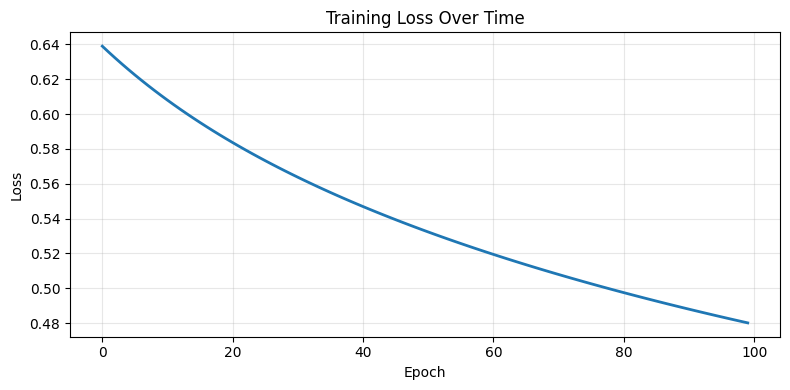

In [4]:
# Training hyperparameters
n_epochs = 100
checkpoint_every = 5  # Save checkpoint every 5 epochs
learning_rate = 0.01

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Storage for checkpoints
checkpoints = []  # List of dicts: {'epoch', 'loss', 'state_dict'}
training_losses = []

# Training loop
print("Starting training...")
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Record loss
    loss_val = loss.item()
    training_losses.append(loss_val)
    
    # Save checkpoint
    if epoch % checkpoint_every == 0 or epoch == n_epochs - 1:
        checkpoint = {
            'epoch': epoch,
            'loss': loss_val,
            'state_dict': deepcopy(model.state_dict())
        }
        checkpoints.append(checkpoint)
        
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{n_epochs}, Loss: {loss_val:.4f}")

print(f"\nTraining complete! Saved {len(checkpoints)} checkpoints.")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(training_losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print(checkpoints[0]["state_dict"])

OrderedDict([('fc1.weight', tensor([[ 0.5405,  0.5870],
        [-0.1656,  0.6495],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6234, -0.5188],
        [ 0.6138,  0.1329],
        [ 0.5227,  0.0956],
        [ 0.3409, -0.0998],
        [ 0.5454,  0.1043],
        [-0.3302,  0.1804],
        [-0.3262, -0.0824],
        [-0.2872,  0.4691],
        [-0.5584, -0.3258],
        [-0.1997, -0.4252],
        [ 0.0668, -0.6984],
        [ 0.6391, -0.6009]])), ('fc1.bias', tensor([ 0.5459,  0.1176, -0.2296,  0.4370,  0.1103,  0.5711,  0.0775, -0.2230,
         0.1902, -0.1916,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1270])), ('fc2.weight', tensor([[ 0.1263, -0.1515, -0.2475, -0.0957, -0.1935,  0.2035,  0.0711,  0.1031,
          0.0780, -0.0042,  0.1958, -0.1766,  0.0159, -0.1706,  0.0758, -0.0879],
        [ 0.0773, -0.0529,  0.2073, -0.1491, -0.1474, -0.1475,  0.2258,  0.0837,
          0.2417, -0.2064, -0.2481, -0.1966, -0.1683,  0.1013,  0.0908,  0.2096]])), (

## 4. Build Graph Representation from Weights

For each checkpoint, we:
- Extract the first layer weight matrix W (shape: [16, 2])
- Construct a bipartite graph: input nodes (0,1) ↔ hidden nodes (2,...,17)
- Define edge function: f(e) = -|w_ij| (sublevel filtration favors large weights)
- Normalize weights per checkpoint for comparability

In [5]:
def extract_bipartite_graph(weight_matrix):
    """
    Extract bipartite graph from weight matrix.
    
    Args:
        weight_matrix: numpy array of shape [hidden_dim, input_dim]
        
    Returns:
        edges: list of (node_i, node_j, filtration_value)
        n_vertices: total number of vertices
    """
    hidden_dim, input_dim = weight_matrix.shape
    
    # Normalize weights by max absolute value
    max_abs = np.abs(weight_matrix).max()
    if max_abs > 0:
        norm_weights = weight_matrix / max_abs
    else:
        norm_weights = weight_matrix
    
    # Build edges
    edges = []
    # Input nodes: 0, 1, ..., input_dim-1
    # Hidden nodes: input_dim, input_dim+1, ..., input_dim+hidden_dim-1
    
    for i in range(input_dim):
        for j in range(hidden_dim):
            node_input = i
            node_hidden = input_dim + j
            weight = norm_weights[j, i]
            
            # Filtration value: -|weight| (sublevel, large weights enter first)
            filt_val = -np.abs(weight)
            
            edges.append((node_input, node_hidden, filt_val))
    
    n_vertices = input_dim + hidden_dim
    return edges, n_vertices

# Test on first checkpoint
test_weights = checkpoints[0]['state_dict']['fc1.weight'].numpy()
test_edges, test_n_vertices = extract_bipartite_graph(test_weights)
print(f"Graph structure: {test_n_vertices} vertices, {len(test_edges)} edges")
print(f"Sample edges (node_i, node_j, filt_val): {test_edges[:3]}")

Graph structure: 18 vertices, 32 edges
Sample edges (node_i, node_j, filt_val): [(0, 2, -0.7739027), (0, 3, -0.23716187), (0, 4, -0.22180378)]


In [9]:
print(test_weights)

[[ 0.5404946   0.5869835 ]
 [-0.16563416  0.64945024]
 [-0.15490805  0.14267734]
 [-0.34427094  0.41533706]
 [ 0.6234233  -0.518786  ]
 [ 0.6138261   0.13289662]
 [ 0.52269304  0.09558079]
 [ 0.34092188 -0.09982793]
 [ 0.5454004   0.10430361]
 [-0.33021998  0.18036184]
 [-0.32616544 -0.08238482]
 [-0.28723538  0.4691017 ]
 [-0.558372   -0.3258311 ]
 [-0.1996691  -0.42516384]
 [ 0.06676664 -0.6984013 ]
 [ 0.63913834 -0.6008826 ]]


## 5. Compute Persistent Homology via Sublevel Filtration

For each checkpoint:
1. Build a simplex tree with vertices and edges
2. Expand to clique complex (dimension 2 for H₁)
3. Compute persistence diagrams for H₀ and H₁

In [11]:
import numpy as np
import gudhi

def compute_persistence_gudhi(edges, n_vertices, max_dim=2):
    """
    edges: list of (i, j, filtration_value)
    Returns: {0: [(b,d),...], 1: [(b,d),...]}
    """
    st = gudhi.SimplexTree()

    # vertices
    for v in range(n_vertices):
        st.insert([v], filtration=0.0)

    # edges
    for i, j, filt in edges:
        st.insert([int(i), int(j)], filtration=float(filt))

    # clique complex up to triangles (captures H1)
    st.expansion(max_dim)

    # compute persistence (this fills internal persistence data)
    st.compute_persistence()

    diagrams = {}
    for dim in (0, 1):
        intervals = st.persistence_intervals_in_dimension(dim)  # shape (N,2)
        # make them plain python tuples
        diagrams[dim] = [ (float(b), float(d)) for b, d in intervals ]

    return diagrams


def compute_persistence_all_checkpoints(checkpoints):
    all_diagrams = []

    for idx, ckpt in enumerate(checkpoints):
        w = ckpt["state_dict"]["fc1.weight"]

        # handle torch tensors robustly
        if hasattr(w, "detach"):
            weights = w.detach().cpu().numpy()
        else:
            weights = np.asarray(w)

        edges, n_vertices = extract_bipartite_graph(weights)
        diagrams = compute_persistence_gudhi(edges, n_vertices)

        all_diagrams.append(diagrams)

        if idx % 5 == 0:
            print(f"Processed checkpoint {idx}/{len(checkpoints)}: "
                  f"H0={len(diagrams[0])}, H1={len(diagrams[1])}")

    return all_diagrams


# Compute persistence for all checkpoints
print("Computing persistent homology for all checkpoints...")
all_diagrams = compute_persistence_all_checkpoints(checkpoints)
print("Persistence computation complete!")

Computing persistent homology for all checkpoints...
Processed checkpoint 0/21: H0=2, H1=0
Processed checkpoint 5/21: H0=2, H1=0
Processed checkpoint 10/21: H0=2, H1=0
Processed checkpoint 15/21: H0=2, H1=0
Processed checkpoint 20/21: H0=2, H1=0
Persistence computation complete!


## 6. Visualize Persistence Diagrams

Show example persistence diagrams from early and late training.

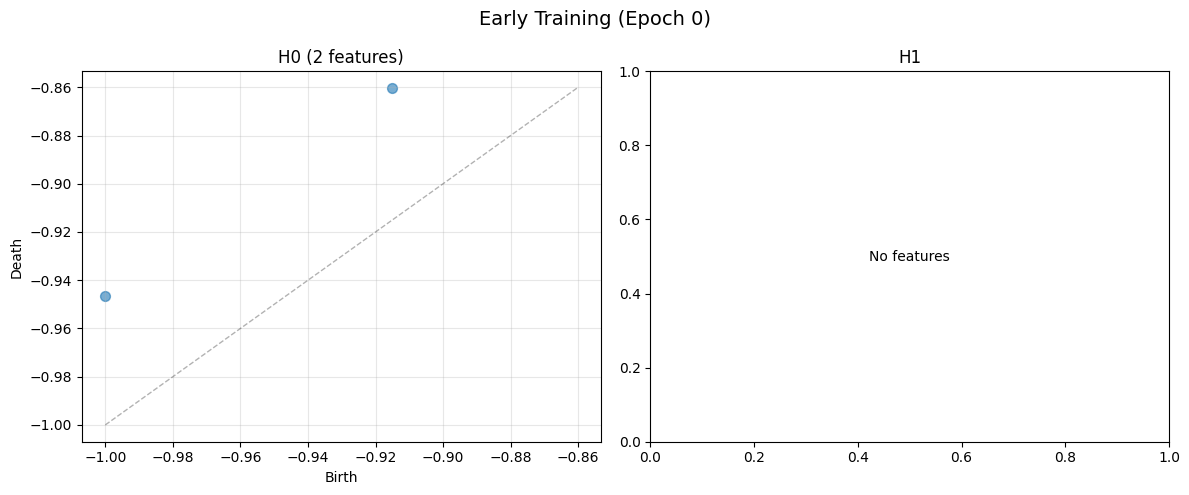

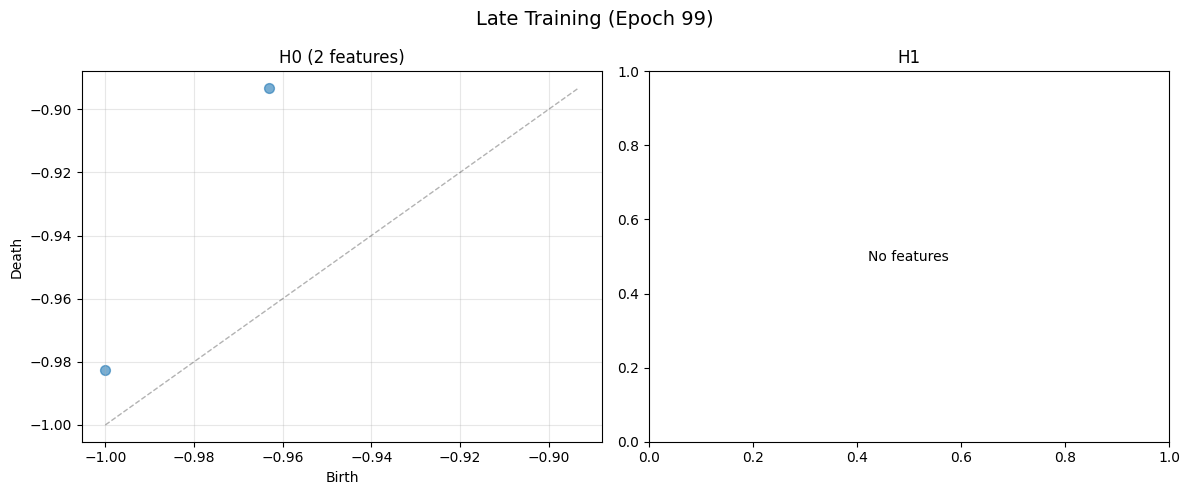

In [12]:
def plot_persistence_diagram(diagrams, title="Persistence Diagram", max_death=None):
    """
    Plot persistence diagram for H0 and H1.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for dim, ax in enumerate(axes):
        dgm = diagrams[dim]
        
        if len(dgm) == 0:
            ax.text(0.5, 0.5, 'No features', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"H{dim}")
            continue
        
        births = [b for b, d in dgm]
        deaths = [d for b, d in dgm]
        
        # Handle infinite deaths
        if max_death is None:
            finite_deaths = [d for d in deaths if not np.isinf(d)]
            max_death = max(finite_deaths) if finite_deaths else 0
        
        # Replace infinities for plotting
        deaths_plot = [d if not np.isinf(d) else max_death * 1.1 for d in deaths]
        
        # Plot points
        ax.scatter(births, deaths_plot, alpha=0.6, s=50)
        
        # Plot diagonal
        lims = [min(births + deaths_plot), max(births + deaths_plot)]
        ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Birth')
        ax.set_ylabel('Death')
        ax.set_title(f"H{dim} ({len(dgm)} features)")
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot early checkpoint (epoch 0)
early_idx = 0
plot_persistence_diagram(
    all_diagrams[early_idx],
    title=f"Early Training (Epoch {checkpoints[early_idx]['epoch']})"
)

# Plot late checkpoint (last epoch)
late_idx = -1
plot_persistence_diagram(
    all_diagrams[late_idx],
    title=f"Late Training (Epoch {checkpoints[late_idx]['epoch']})"
)

## 7. Vectorize Persistence into Betti Curves

Convert persistence diagrams into fixed-length feature vectors using Betti curves.

For each dimension p and threshold α:
$$\beta_p(\alpha) = \#\{(b_i, d_i) : b_i \leq \alpha < d_i\}$$

In [13]:
def compute_betti_curve(diagram, alpha_grid, max_death_cap):
    """
    Compute Betti curve for a persistence diagram.
    
    Args:
        diagram: list of (birth, death) tuples
        alpha_grid: array of threshold values
        max_death_cap: value to replace infinite deaths
        
    Returns:
        betti_values: array of Betti numbers at each threshold
    """
    betti_values = np.zeros(len(alpha_grid))
    
    for birth, death in diagram:
        # Replace infinite death with cap
        if np.isinf(death):
            death = max_death_cap
        
        # Count intervals covering each alpha
        for i, alpha in enumerate(alpha_grid):
            if birth <= alpha < death:
                betti_values[i] += 1
    
    return betti_values

def vectorize_all_diagrams(all_diagrams, n_grid_points=50):
    """
    Vectorize all persistence diagrams into Betti curves.
    
    Returns:
        feature_matrix: array of shape [n_checkpoints, 2*n_grid_points]
        alpha_grid: the threshold grid used
    """
    # Determine global filtration range
    all_births = []
    all_deaths = []
    
    for diagrams in all_diagrams:
        for dim in [0, 1]:
            for birth, death in diagrams[dim]:
                all_births.append(birth)
                if not np.isinf(death):
                    all_deaths.append(death)
    
    min_alpha = min(all_births) if all_births else -1.0
    max_alpha = max(all_deaths) if all_deaths else 0.0
    max_death_cap = max_alpha + 0.1 * abs(max_alpha)
    
    # Create threshold grid
    alpha_grid = np.linspace(min_alpha, max_alpha, n_grid_points)
    
    # Compute Betti curves for all checkpoints
    n_checkpoints = len(all_diagrams)
    feature_matrix = np.zeros((n_checkpoints, 2 * n_grid_points))
    
    for i, diagrams in enumerate(all_diagrams):
        # H0 Betti curve
        betti_0 = compute_betti_curve(diagrams[0], alpha_grid, max_death_cap)
        # H1 Betti curve
        betti_1 = compute_betti_curve(diagrams[1], alpha_grid, max_death_cap)
        
        # Concatenate
        feature_matrix[i, :n_grid_points] = betti_0
        feature_matrix[i, n_grid_points:] = betti_1
    
    return feature_matrix, alpha_grid

# Vectorize all diagrams
print("Vectorizing persistence diagrams into Betti curves...")
feature_matrix, alpha_grid = vectorize_all_diagrams(all_diagrams, n_grid_points=50)
print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Alpha grid range: [{alpha_grid.min():.3f}, {alpha_grid.max():.3f}]")

Vectorizing persistence diagrams into Betti curves...
Feature matrix shape: (21, 100)
Alpha grid range: [-1.000, -0.860]


## 8. Visualize Betti Curves

Compare Betti curves from early vs late training.

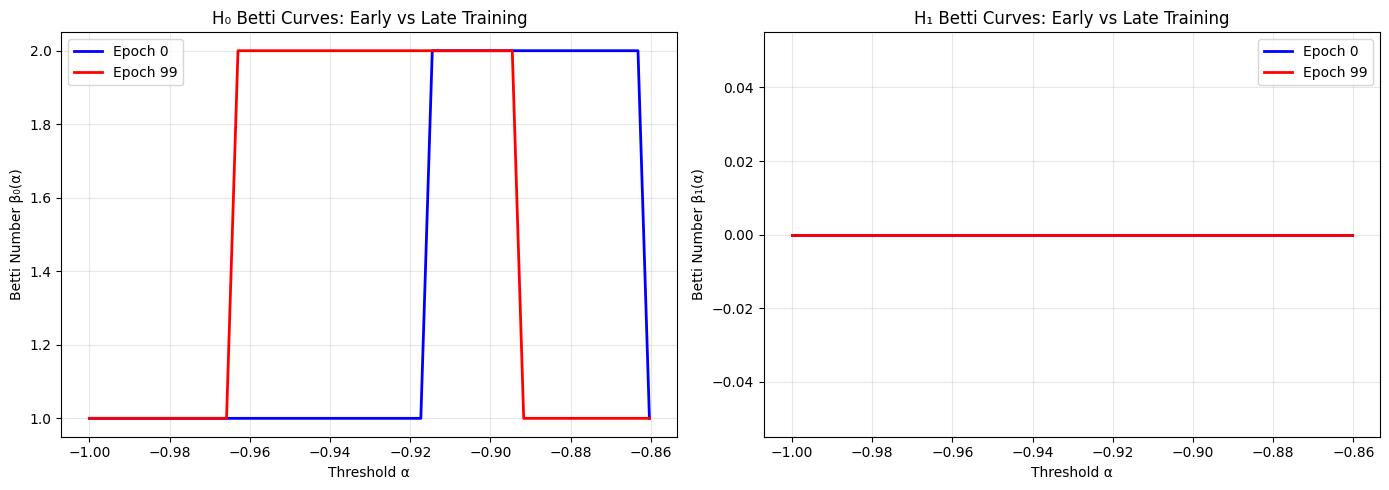

In [15]:
n_grid = len(alpha_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# H0 Betti curves
axes[0].plot(alpha_grid, feature_matrix[0, :n_grid], 'b-', linewidth=2, 
             label=f"Epoch {checkpoints[0]['epoch']}")
axes[0].plot(alpha_grid, feature_matrix[-1, :n_grid], 'r-', linewidth=2, 
             label=f"Epoch {checkpoints[-1]['epoch']}")
axes[0].set_xlabel('Threshold α')
axes[0].set_ylabel('Betti Number β₀(α)')
axes[0].set_title('H₀ Betti Curves: Early vs Late Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# H1 Betti curves
axes[1].plot(alpha_grid, feature_matrix[0, n_grid:], 'b-', linewidth=2, 
             label=f"Epoch {checkpoints[0]['epoch']}")
axes[1].plot(alpha_grid, feature_matrix[-1, n_grid:], 'r-', linewidth=2, 
             label=f"Epoch {checkpoints[-1]['epoch']}")
axes[1].set_xlabel('Threshold α')
axes[1].set_ylabel('Betti Number β₁(α)')
axes[1].set_title('H₁ Betti Curves: Early vs Late Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Multi-Dimensional Spline Fitting Over Time

Fit smoothing splines to each dimension of the feature vectors over training time.

In [16]:
def fit_splines_to_features(feature_matrix, times, smoothing_factor=0.5):
    """
    Fit univariate splines to each feature dimension.
    
    Args:
        feature_matrix: array of shape [n_times, n_features]
        times: array of time points (e.g., checkpoint epochs)
        smoothing_factor: spline smoothing parameter
        
    Returns:
        splines: list of UnivariateSpline objects
    """
    n_times, n_features = feature_matrix.shape
    splines = []
    
    for i in range(n_features):
        y = feature_matrix[:, i]
        # Fit spline with smoothing
        spline = UnivariateSpline(times, y, s=smoothing_factor, k=3)
        splines.append(spline)
    
    return splines

def evaluate_splines(splines, times_dense):
    """
    Evaluate splines on a dense time grid.
    
    Returns:
        smoothed_matrix: array of shape [len(times_dense), n_features]
    """
    n_features = len(splines)
    smoothed_matrix = np.zeros((len(times_dense), n_features))
    
    for i, spline in enumerate(splines):
        smoothed_matrix[:, i] = spline(times_dense)
    
    return smoothed_matrix

# Prepare time points (normalized to [0, 1])
checkpoint_epochs = np.array([ckpt['epoch'] for ckpt in checkpoints])
times_normalized = checkpoint_epochs / checkpoint_epochs.max()
times_dense = np.linspace(0, 1, 200)

# Fit splines
print("Fitting splines to feature trajectories...")
smoothing_factor = 1.0  # Adjust for more/less smoothing
splines = fit_splines_to_features(feature_matrix, times_normalized, smoothing_factor)

# Evaluate on dense grid
smoothed_features = evaluate_splines(splines, times_dense)
print(f"Smoothed feature matrix shape: {smoothed_features.shape}")

Fitting splines to feature trajectories...
Smoothed feature matrix shape: (200, 100)


## 10. Visualize Temporal Evolution with Splines

Plot raw Betti values and spline-smoothed trajectories over training time.

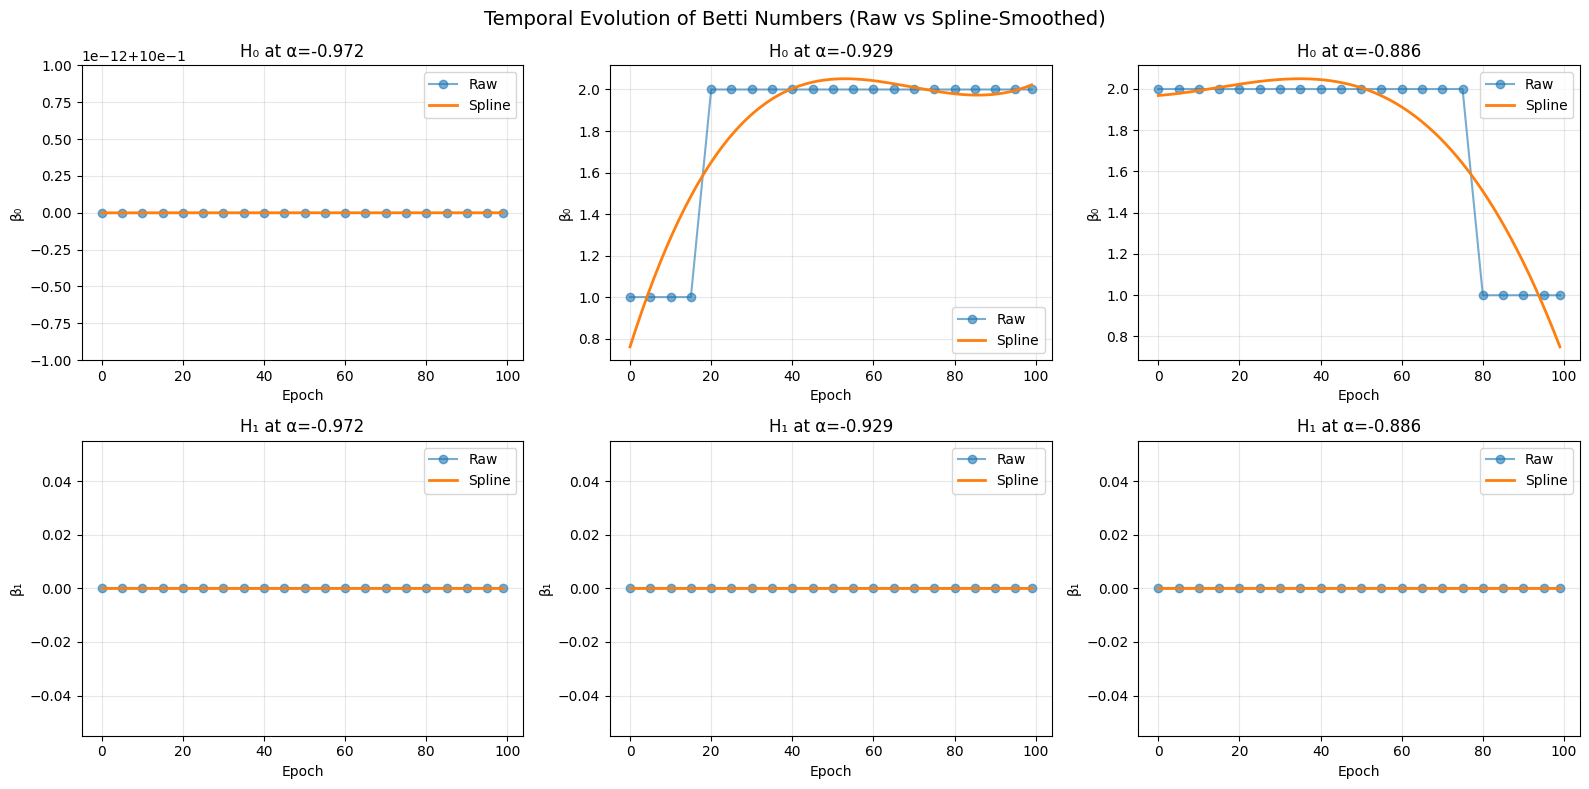

In [17]:
# Select a few alpha indices to visualize
n_grid = len(alpha_grid)
alpha_indices = [10, 25, 40]  # Early, middle, late in the alpha range

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, alpha_idx in enumerate(alpha_indices):
    # H0 Betti number at this alpha
    raw_h0 = feature_matrix[:, alpha_idx]
    smooth_h0 = smoothed_features[:, alpha_idx]
    
    axes[0, col].plot(checkpoint_epochs, raw_h0, 'o-', alpha=0.6, label='Raw')
    axes[0, col].plot(times_dense * checkpoint_epochs.max(), smooth_h0, 
                      linewidth=2, label='Spline')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('β₀')
    axes[0, col].set_title(f"H₀ at α={alpha_grid[alpha_idx]:.3f}")
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)
    
    # H1 Betti number at this alpha
    raw_h1 = feature_matrix[:, n_grid + alpha_idx]
    smooth_h1 = smoothed_features[:, n_grid + alpha_idx]
    
    axes[1, col].plot(checkpoint_epochs, raw_h1, 'o-', alpha=0.6, label='Raw')
    axes[1, col].plot(times_dense * checkpoint_epochs.max(), smooth_h1, 
                      linewidth=2, label='Spline')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('β₁')
    axes[1, col].set_title(f"H₁ at α={alpha_grid[alpha_idx]:.3f}")
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Temporal Evolution of Betti Numbers (Raw vs Spline-Smoothed)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. PCA Visualization of Feature Trajectories

Project the high-dimensional feature vectors into 2D using PCA to visualize the training trajectory.

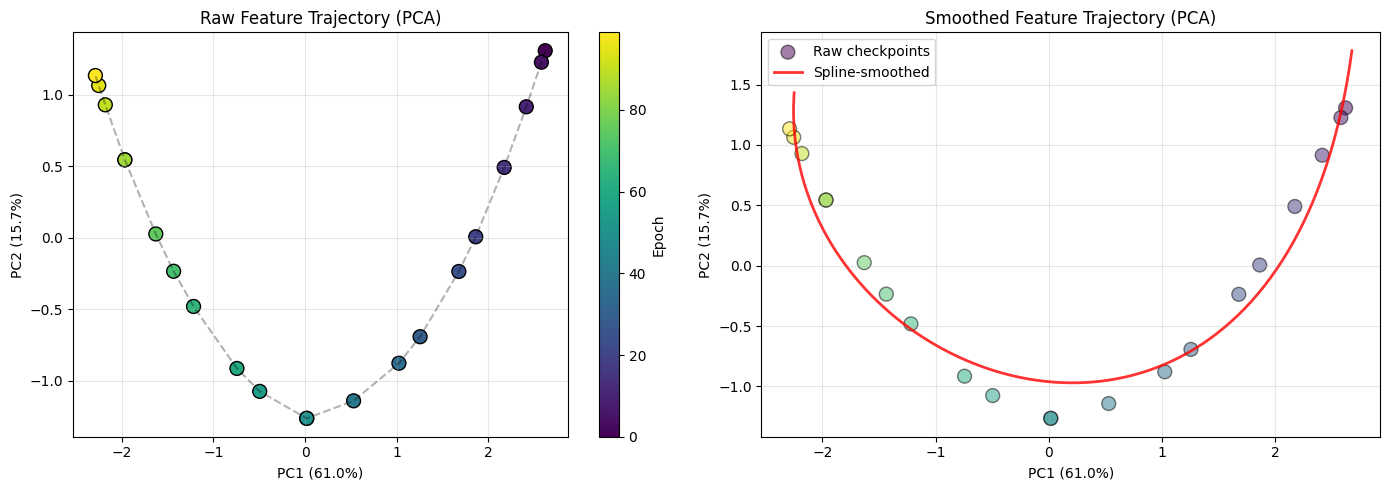


PCA explained variance: 61.0% (PC1), 15.7% (PC2)


In [18]:
# Apply PCA to raw features
pca = PCA(n_components=2)
features_pca = pca.fit_transform(feature_matrix)

# Apply same PCA to smoothed features
smoothed_pca = pca.transform(smoothed_features)

# Plot trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw trajectory
scatter = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                          c=checkpoint_epochs, cmap='viridis', s=100, 
                          edgecolors='k', linewidth=1)
axes[0].plot(features_pca[:, 0], features_pca[:, 1], 'k--', alpha=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Raw Feature Trajectory (PCA)')
plt.colorbar(scatter, ax=axes[0], label='Epoch')
axes[0].grid(True, alpha=0.3)

# Smoothed trajectory
scatter2 = axes[1].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=checkpoint_epochs, cmap='viridis', s=100, 
                           edgecolors='k', linewidth=1, alpha=0.5, label='Raw checkpoints')
axes[1].plot(smoothed_pca[:, 0], smoothed_pca[:, 1], 'r-', linewidth=2, 
             alpha=0.8, label='Spline-smoothed')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Smoothed Feature Trajectory (PCA)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_[0]*100:.1f}% (PC1), "
      f"{pca.explained_variance_ratio_[1]*100:.1f}% (PC2)")

## 12. Summary and Limitations

### What We Demonstrated:
1. **Sublevel Filtration**: We used f(e) = -|w_ij| on edges, so large-magnitude weights enter the filtration first. This captures how strongly connected the network's input and hidden layers are.

2. **Persistent Homology**: 
   - **H₀** tracks connected components (how the graph fragments as we increase threshold)
   - **H₁** tracks loops/cycles (limited in bipartite graphs, but methodology is sound)

3. **Betti Curves**: Fixed-length vectorization of persistence diagrams enabling time-series analysis

4. **Spline Smoothing**: Multi-dimensional smoothing of feature trajectories to reduce noise and reveal trends

### Limitations and Extensions:

**Graph Construction:**
- Bipartite graphs from weight matrices have limited topological structure (few or no cycles)
- **Better alternatives**: 
  - Build graphs within layers using neuron activation correlations
  - Use distance-based point clouds from neuron embeddings
  - Apply Vietoris-Rips or Alpha complexes instead of clique complexes

**Filtration:**
- Currently uses simple weight magnitude
- Could use gradient magnitudes, activations, or information-theoretic measures

**Feature Engineering:**
- Betti curves are just one vectorization method
- Consider: persistence landscapes, persistence images, Wasserstein distances

**Statistical Analysis:**
- This is a single training run
- For research: run multiple seeds, compute confidence intervals, test hypotheses

**Scalability:**
- This toy example uses a 16-neuron hidden layer
- For larger networks: sample neurons, use dimensionality reduction, or employ approximate TDA methods

### Research Directions:
- Correlate topological features with generalization, robustness, or training phase transitions
- Compare different architectures or optimization algorithms
- Study critical periods or loss landscape geometry through TDA lens
- Develop topological regularizers for training

---

**This notebook provides a complete, minimal pipeline for TDA-based training dynamics analysis. All code runs top-to-bottom with no external files required.**